<a href="https://colab.research.google.com/github/Dinobenia/Teste-Deep/blob/main/Final_Projeto_Pinguins.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Beatriz Caixeta Grosara
Stefanie Maria Oliveira

#Bibliotecas e Funções

In [1]:
import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)



!pip install pyvis
from pyvis.network import Network
import pandas as pd
import random
from google.colab import files

pd.set_option('display.max_colwidth', None)

def make_graph(grules):
  # Criando a rede com cdn_resources configurado para 'remote' e habilitando física
  net = Network(height="750px", width="100%", bgcolor="#222222", font_color="white", notebook=True, directed=True, cdn_resources='in_line')

  # Adicionando nós e arestas com setas
  for index, row in grules.iterrows():
      antecedents = list(row['antecedents'])
      consequents = list(row['consequents'])

      # Adicionando cada antecedente como um nó
      for ant in antecedents:
          net.add_node(ant, ant, title=ant)

      # Adicionando cada consequente como um nó
      for con in consequents:
          net.add_node(con, con, title=con)

      # Adicionando arestas para cada par antecedente-consequente
      for ant in antecedents:
          for con in consequents:
              edge_title = f"Confidence: {row['confidence']:.2f}, Lift: {row['lift']:.2f}"
              net.add_edge(ant, con, value=row['confidence'], title=edge_title)



  # Salvando e fazendo o download do grafo
  net.save_graph("supermarket_associations_directed.html")
  files.download("supermarket_associations_directed.html")


import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)

pd.set_option('display.max_colwidth', None)

import pandas as pd
import networkx as nx
from pyvis.network import Network
from google.colab import files

def make_graph2(grules):
    G = nx.DiGraph()

    # Adicionando nós e arestas
    for index, row in grules.iterrows():
        # Criando rótulos para os nós de antecedente e consequente
        antecedent_items = sorted(map(str, row['antecedents']))
        consequent_items = sorted(map(str, row['consequents']))
        antecedent_label = ', '.join(antecedent_items)
        consequent_label = ', '.join(consequent_items)

        # Adicionando os nós de antecedente e consequente se ainda não existirem
        if not G.has_node(antecedent_label):
            G.add_node(antecedent_label, title=antecedent_label)
        if not G.has_node(consequent_label):
            G.add_node(consequent_label, title=consequent_label)

        # Adicionando uma aresta entre o antecedente e o consequente
        G.add_edge(
            antecedent_label,
            consequent_label,
            title=f"Confiança: {row['confidence']:.2f}, Lift: {row['lift']:.2f}",
            confidence=row['confidence'],
            lift=row['lift']
        )

    # Criando a rede com pyvis
    net = Network(
        height="750px",
        width="100%",
        bgcolor="#222222",
        font_color="white",
        notebook=True,
        directed=True,
        cdn_resources='in_line'
    )

    # Convertendo o grafo networkx para pyvis
    net.from_nx(G)

    # Ajustando estilos e interações
    for node in net.nodes:
        node_label = node['label']
        node['title'] = node_label
        node['shape'] = 'box'  # Opcional: para melhor visualização de conjuntos de itens

        # Verificando se o nó representa um único item
        if ',' not in node_label:
            # Verificando se o item começa com 'DS_cluster'
            if node_label.startswith('DS_cluster'):
                # Destaque para os nós que atendem ao critério
                node['color'] = 'red'         # Cor diferenciada
                node['font'] = {'size': 14}   # Fonte maior
                node['borderWidth'] = 2       # Borda mais espessa
                node['size'] = 40             # Nó maior
            else:
                # Estilo padrão para nós individuais
                node['color'] = '#1f78b4'
                node['size'] = 5
                node['font'] = {'size': 2}   # Fonte menor
        else:
            # Estilo para nós que representam múltiplos itens
            node['color'] = '#6a3d9a'
            node['size'] = 5
            node['font'] = {'size': 2}   # Fonte menor

    for edge in net.edges:
        edge['title'] = edge['title']
        edge['value'] = edge['confidence']  # Ajusta a espessura da aresta com base na confiança

    # Habilitando a física para movimentação dinâmica dos nós
    net.show_buttons(filter_=['physics'])
    net.toggle_physics(True)

    # Salvando e fazendo o download do grafo
    net.save_graph("supermarket_associations_directed.html")
    files.download("supermarket_associations_directed.html")




   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 756.0/756.0 kB 33.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 50.3 MB/s eta 0:00:00


In [2]:
import zipfile
def descompactar_arquivo(nome_arquivo_zip, destino):
  """
  Descompacta um arquivo zip.

  Args:
    nome_arquivo_zip: O nome do arquivo zip a ser descompactado.
    destino: O diretório onde os arquivos serão extraídos.
  """
  try:
    with zipfile.ZipFile(nome_arquivo_zip, 'r') as zip_ref:
      zip_ref.extractall(destino)
    print(f"Arquivo {nome_arquivo_zip} descompactado com sucesso para {destino}")
  except FileNotFoundError:
    print(f"Arquivo {nome_arquivo_zip} não encontrado.")
  except Exception as e:
    print(f"Erro ao descompactar o arquivo: {e}")


import numpy as np
import math
import matplotlib.pyplot as plt
from matplotlib import colormaps

def make_spider(df_plot):

    # Seleciona apenas as colunas numéricas, excluindo a coluna "cluster" e "count"
    num_col = df_plot.select_dtypes(include=['float64', 'int64']).columns.difference(["cluster", "count"])

    n_cols = df_plot['cluster'].unique().shape[0]

    # Normaliza as colunas numéricas
    df_plot.loc[:, num_col] = df_plot[num_col].div(df_plot[num_col].max(axis=0))
    df_plot = df_plot.fillna(0)

    # Seleciona a paleta de cores
    palette = colormaps.get_cmap("Set2")  # Corrigido para aceitar apenas dois argumentos

    # Definir categorias sem a coluna "cluster" e "count"
    categories = list(df_plot[num_col].columns)
    N = len(categories)

    # Ângulos para o gráfico polar
    angles = [n / float(N) * 2 * math.pi for n in range(N)]
    angles += angles[:1]

    # Configurações da figura
    my_dpi = 96
    fig, axes = plt.subplots(df_plot.shape[0] // n_cols, n_cols, figsize=(1500 / my_dpi, 1500 / my_dpi), dpi=my_dpi, subplot_kw={"projection": "polar"})
    axes = axes.ravel()

    for idx, ax in enumerate(axes):
        color = palette(idx)

        # Seleciona a linha atual
        row = df_plot.iloc[idx]

        # Configurações do gráfico polar
        ax.set_theta_offset(math.pi / 2)
        ax.set_theta_direction(-1)

        ax.set_xticks(angles[:-1], categories, color="grey", size=7)

        ax.set_rlabel_position(0)
        ax.set_yticks([0.33, 0.66, 0.99], ["0.3", "0.6", "1"], color="grey", size=10)
        ax.set_ylim(0, 1)

        # Valores para o gráfico, sem as colunas "cluster" e "count"
        values = row[num_col].values.flatten().tolist()
        values += values[:1]

        # Plotar o gráfico
        ax.plot(angles, values, color=color, linewidth=1.5, linestyle='solid')
        ax.fill(angles, values, color=color, alpha=0.4)

        # Título com o número de registros (coluna "count")
        ax.set_title(f"Persona {row['cluster']} - {int(row['count'])} registros", size=14, color=color, y=1.1)

    plt.tight_layout()
    plt.show()

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

def plot_boxplots(df, columns, outline=True):
    """
    Plota boxplots verticais para variáveis numéricas selecionadas em um DataFrame,
    exibe os valores dos quartis e a média.

    Parâmetros:
    -----------
    df : pandas.DataFrame
        O DataFrame contendo os dados.
    columns : list
        Lista de nomes de colunas que se deseja plotar.
    outline : bool, opcional (default=True)
        Se True, inclui outliers no boxplot.
    """
    # Verificar se as colunas fornecidas são numéricas
    num_columns = [col for col in columns if pd.api.types.is_numeric_dtype(df[col])]

    # Checa se existem colunas numéricas para plotar
    if not num_columns:
        raise ValueError("Nenhuma das colunas fornecidas é numérica.")

    # Criar os boxplots
    plt.figure(figsize=(4, len(num_columns) * 4))  # Ajuste de tamanho baseado no número de colunas

    for i, col in enumerate(num_columns, 1):
        plt.subplot(len(num_columns), 1, i)

        # Criar o boxplot vertical
        sns.boxplot(data=df, y=col, showfliers=outline, orient="v")

        # Calcular os quartis e a média
        quartile_25 = df[col].quantile(0.25)
        quartile_50 = df[col].median()  # ou quantile(0.50)
        quartile_75 = df[col].quantile(0.75)

        # Calcular os limites para os outliers
        iqr = quartile_75 - quartile_25
        lower_bound = quartile_25 - 1.5 * iqr
        upper_bound = quartile_75 + 1.5 * iqr

        # Exibir os limites dos outliers
        plt.text(0, lower_bound, f'Início Outliers Inf: {lower_bound:,.2f}', horizontalalignment='center', color='purple', weight='bold')
        plt.text(0, upper_bound, f'Início Outliers Sup: {upper_bound:,.2f}', horizontalalignment='center', color='purple', weight='bold')


        # Plotar os valores dos quartis e da média
        plt.text(0, quartile_25, f'Q1: {quartile_25:,.2f}', horizontalalignment='center', color='blue', weight='bold')
        plt.text(0, quartile_50, f'Q2 (Mediana): {quartile_50:,.2f}', horizontalalignment='center', color='blue', weight='bold')
        plt.text(0, quartile_75, f'Q3: {quartile_75:,.2f}', horizontalalignment='center', color='blue', weight='bold')

        # Título e rótulo do eixo Y
        plt.title(f'Boxplot de {col}')
        plt.ylabel(col)

    plt.tight_layout()
    plt.show()

import matplotlib.pyplot as plt
def plot_pie_charts(df, category_col, split_col=None):
    """
    Plota gráficos de pizza. Se `split_col` for fornecido, cria um gráfico de pizza
    para cada valor único em `split_col`, caso contrário, cria um único gráfico de pizza.

    Parâmetros:
    -----------
    df : pandas.DataFrame
        O DataFrame contendo os dados.
    category_col : str
        Nome da coluna com as categorias para serem fatiadas no gráfico de pizza.
    split_col : str, opcional
        Nome da coluna que separará cada gráfico de pizza.
    """
    # Se split_col for None, gerar apenas um gráfico de pizza para a coluna category_col
    if split_col is None:
        counts = df[category_col].value_counts()

        # Criar o gráfico de pizza
        plt.figure(figsize=(5, 5))
        plt.pie(counts, labels=counts.index, autopct='%1.1f%%', startangle=90, colors=plt.cm.Set2.colors)
        plt.title(f'Gráfico de pizza para {category_col}', size=14)
        plt.tight_layout()
        plt.show()

    else:
        # Obter os valores únicos da coluna split_col
        split_values = df[split_col].unique()

        # Configurar o tamanho da figura
        fig, axes = plt.subplots(nrows=1, ncols=len(split_values), figsize=(5 * len(split_values), 5))

        # Caso haja apenas um gráfico, convertemos o eixo para uma lista
        if len(split_values) == 1:
            axes = [axes]

        # Gerar um gráfico de pizza para cada valor em split_col
        for i, value in enumerate(split_values):
            ax = axes[i]

            # Filtrar o DataFrame para o valor atual de split_col
            df_filtered = df[df[split_col] == value]

            # Contar as frequências de cada categoria
            counts = df_filtered[category_col].value_counts()

            # Criar o gráfico de pizza
            ax.pie(counts, labels=counts.index, autopct='%1.1f%%', startangle=90, colors=plt.cm.Set2.colors)
            ax.set_title(f'{split_col}: {value}', size=14)

        plt.tight_layout()
        plt.show()


import matplotlib.pyplot as plt
import pandas as pd

def plot_stacked_bar_chart(df, category_col, split_col=None, stacked = True):
    """
    Plota gráficos de barras empilhadas. Se `split_col` for fornecido, cria um gráfico
    de barras empilhadas para cada valor único em `split_col`, caso contrário, cria um único gráfico.

    Parâmetros:
    -----------
    df : pandas.DataFrame
        O DataFrame contendo os dados.
    category_col : str
        Nome da coluna com as categorias para serem representadas no gráfico.
    split_col : str, opcional
        Nome da coluna que separará cada gráfico de barras empilhadas.
    """
    if split_col is None:
        # Contar as frequências de cada categoria
        counts = df[category_col].value_counts(normalize=True)  # Normalizado para que a barra tenha a mesma altura

        # Criar o gráfico de barras empilhadas
        counts.plot(kind='bar', stacked=stacked, figsize=(7, 5), color=plt.cm.Set2.colors)
        plt.title(f'Gráfico de barras empilhadas para {category_col}', size=14)
        plt.ylabel('Proporção')
        plt.xlabel(category_col)
        plt.tight_layout()
        plt.show()

    else:
        # Pivotar a tabela para calcular as proporções
        df_grouped = df.groupby([split_col, category_col]).size().unstack().fillna(0)

        # Normalizar para que a barra tenha a mesma altura (1)
        df_grouped_norm = df_grouped.div(df_grouped.sum(axis=1), axis=0)

        # Criar o gráfico de barras empilhadas
        df_grouped_norm.plot(kind='bar', stacked=stacked, figsize=(10, 7), color=plt.cm.Set2.colors)

        # Configurar os rótulos e título
        plt.title(f'Gráfico de barras empilhadas para {split_col} e {category_col}', size=14)
        plt.ylabel('Proporção')
        plt.xlabel(split_col)
        plt.tight_layout()
        plt.show()


def plot_kde(df, var):
  plt.figure(figsize=(10, 6))
  sns.kdeplot(data=df, x=var, fill=True,  palette='Set2')
  plt.title(f'Histograma da Variável {var} por Cluster')
  plt.xlabel(f'{var}')
  plt.ylabel('Frequência')
  plt.show()

#Obter Dados

Procurar 3 variaveis

In [3]:
import pandas as pd
import requests
import os

# URL do dataset dos Pinguins
url = 'https://raw.githubusercontent.com/mwaskom/seaborn-data/master/penguins.csv'
filename = 'penguins.csv'

# Download
response = requests.get(url)
with open(filename, 'wb') as f:
    f.write(response.content)
print(f"Arquivo {filename} baixado com sucesso!")

# Carregando os dados
df_penguins = pd.read_csv(filename)

# Visualizar
print("\nPrimeiras linhas do dataset:")
display(df_penguins.head())

print("\nInformações sobre as colunas:")
df_penguins.info()

#espécie
#ilha
#comprimento do bico
#profundidade do bico
#comprimento da nadadeira
#massa corporal
#sexo

Arquivo penguins.csv baixado com sucesso!

Primeiras linhas do dataset:


,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,MALE
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,FEMALE
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,FEMALE
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,FEMALE



Informações sobre as colunas:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            344 non-null    object 
 1   island             344 non-null    object 
 2   bill_length_mm     342 non-null    float64
 3   bill_depth_mm      342 non-null    float64
 4   flipper_length_mm  342 non-null    float64
 5   body_mass_g        342 non-null    float64
 6   sex                333 non-null    object 
dtypes: float64(4), object(3)
memory usage: 18.9+ KB


In [4]:
# Diversidade das espécies
print("Quantidade de pinguins por espécie:")
print(df_penguins['species'].value_counts()) # Entender a distribuição das espécies de pinguins

Quantidade de pinguins por espécie:
species
Adelie       152
Gentoo       124
Chinstrap     68
Name: count, dtype: int64


In [5]:
# Diversidade das Ilhas
print("\nQuantidade de pinguins por ilha:")
print(df_penguins['island'].value_counts()) #Entender a distribuição das ilhas


Quantidade de pinguins por ilha:
island
Biscoe       168
Dream        124
Torgersen     52
Name: count, dtype: int64


In [6]:
# Copia do dos dados originais
df_trabalho = df_penguins.copy()

print(f"Base de trabalho pronta! Analisaremos {df_trabalho.shape[0]} pinguins de todas as ilhas.")
display(df_trabalho.head())


Base de trabalho pronta! Analisaremos 344 pinguins de todas as ilhas.


,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,MALE
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,FEMALE
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,FEMALE
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,FEMALE


**PREPARAÇÃO DOS DADOS**

In [7]:
# Filtro de colunas das biologias dos pinguins "Gabarito de Conferência"
colunas_selecionadas = [
    'species',
    'island',
    'bill_length_mm',
    'bill_depth_mm',
    'flipper_length_mm',
    'body_mass_g',
    'sex'
]

df_final = df_trabalho[colunas_selecionadas].copy()


In [8]:
# Remoção de duplicatas e valores nulos
df_final = df_final.drop_duplicates()
df_final = df_final.dropna()

# Reset de ìndice
df_final = df_final.reset_index(drop=True)

# Verificação
print(f"Limpeza concluída! Agora temos {len(df_final)} pinguins prontos.")
df_original = pd.read_csv('penguins.csv')
print(f"No início, tínhamos: {len(df_original)} pinguins.")
display(df_final.head())

Limpeza concluída! Agora temos 333 pinguins prontos.
No início, tínhamos: 344 pinguins.


,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,MALE
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,FEMALE
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,FEMALE
3,Adelie,Torgersen,36.7,19.3,193.0,3450.0,FEMALE
4,Adelie,Torgersen,39.3,20.6,190.0,3650.0,MALE


In [9]:
# Resultado da base pronta para a análise
print(f"Total de registros após limpeza e seleção: {len(df_final)}")
display(df_final.head())

Total de registros após limpeza e seleção: 333


,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,MALE
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,FEMALE
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,FEMALE
3,Adelie,Torgersen,36.7,19.3,193.0,3450.0,FEMALE
4,Adelie,Torgersen,39.3,20.6,190.0,3650.0,MALE


**PADRONIZAÇÃO E CONCATENIZAÇÃO**

In [10]:
from sklearn.preprocessing import StandardScaler
import pickle
import pandas as pd

# Colunas numéricas para o agrupamento
colunas_numericas = ['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g']

# StandardScale fórmula matemática: z = valor - media / desvio padrão
scaler = StandardScaler()

# Normalizando os dados
df_cluster_padronizado = scaler.fit_transform(df_final[colunas_numericas])

# Salvar Scaler
with open('scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

# Novo dataframe com as variáveis padronizadas e o sufixo
df_padronizado = pd.DataFrame(
    df_cluster_padronizado,
    columns=[col + '_PADRONIZADA' for col in colunas_numericas]
)

# Concatenação
df_final = df_final.reset_index(drop=True)
df_padronizado = df_padronizado.reset_index(drop=True)

df_final = pd.concat([df_final, df_padronizado], axis=1)

print("Agora funcionou! Padronização concluída e Scaler salvo.")
display(df_final.head())

Agora funcionou! Padronização concluída e Scaler salvo.


,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,bill_length_mm_PADRONIZADA,bill_depth_mm_PADRONIZADA,flipper_length_mm_PADRONIZADA,body_mass_g_PADRONIZADA
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,MALE,-0.896042,0.780732,-1.426752,-0.568475
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,FEMALE,-0.822788,0.119584,-1.069474,-0.506286
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,FEMALE,-0.676280,0.424729,-0.426373,-1.190361
3,Adelie,Torgersen,36.7,19.3,193.0,3450.0,FEMALE,-1.335566,1.085877,-0.569284,-0.941606
4,Adelie,Torgersen,39.3,20.6,190.0,3650.0,MALE,-0.859415,1.747026,-0.783651,-0.692852


**CLUSTERIZAÇÃO**

100%|██████████| 18/18 [00:01<00:00, 17.24it/s]


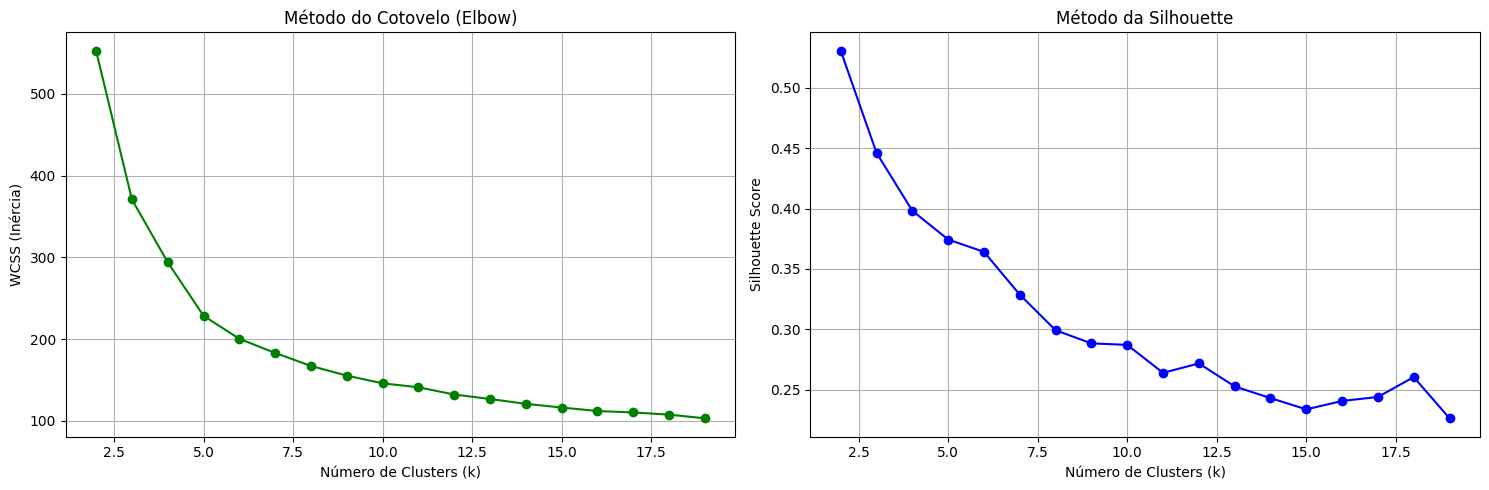

In [11]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
from tqdm import tqdm

# Definindo as colunas padronizadas que vou testar
colunas_numericas_padronizadas = [
    'bill_length_mm_PADRONIZADA',
    'bill_depth_mm_PADRONIZADA',
    'flipper_length_mm_PADRONIZADA',
    'body_mass_g_PADRONIZADA'
]

wcss = []
silhouette_scores = []
K = range(2, 20) # Testando de 2 a 20

for k in tqdm(K):
    # Treinando o K-Means
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(df_final[colunas_numericas_padronizadas])

    # Gráfico do Cotovelo
    wcss.append(kmeans.inertia_)

    # Gráfico de Silhouette
    score = silhouette_score(df_final[colunas_numericas_padronizadas], kmeans.labels_)
    silhouette_scores.append(score)


plt.figure(figsize=(15, 5))

# Gráfico Método do Cotovelo
plt.subplot(1, 2, 1)
plt.plot(K, wcss, 'go-')
plt.title('Método do Cotovelo (Elbow)')
plt.xlabel('Número de Clusters (k)')
plt.ylabel('WCSS (Inércia)')
plt.grid(True)

# Gráfico Método da Silhouette
plt.subplot(1, 2, 2)
plt.plot(K, silhouette_scores, 'bo-')
plt.title('Método da Silhouette')
plt.xlabel('Número de Clusters (k)')
plt.ylabel('Silhouette Score')
plt.grid(True)

plt.tight_layout()
plt.show()

# O Método do Cotovelo mostra uma dobra clara na região de 3 clusters
# Por meio do conhecimento dos dados eu escolhi 3 Clusters no Método d Silhouette

In [18]:
# MODELO FINAL COM 5 CLUSTERS
from sklearn.cluster import KMeans

k_final = 5

# Rodando o algoritmo
kmeans_final = KMeans(n_clusters=k_final, random_state=42, n_init=10)
df_final['cluster'] = kmeans_final.fit_predict(df_final[[
    'bill_length_mm_PADRONIZADA',
    'bill_depth_mm_PADRONIZADA',
    'flipper_length_mm_PADRONIZADA',
    'body_mass_g_PADRONIZADA'
]])

df_final['DS_cluster'] = df_final['cluster'].apply(lambda x: f'Cluster {x}')

print("Pinguins agrupados com sucesso!")
print(df_final['DS_cluster'].value_counts())
display(df_final.head())

Pinguins agrupados com sucesso!
DS_cluster
Cluster 2    89
Cluster 4    65
Cluster 3    62
Cluster 0    60
Cluster 1    57
Name: count, dtype: int64


,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,bill_length_mm_PADRONIZADA,bill_depth_mm_PADRONIZADA,flipper_length_mm_PADRONIZADA,body_mass_g_PADRONIZADA,cluster,DS_cluster
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,MALE,-0.896042,0.780732,-1.426752,-0.568475,2,Cluster 2
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,FEMALE,-0.822788,0.119584,-1.069474,-0.506286,2,Cluster 2
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,FEMALE,-0.676280,0.424729,-0.426373,-1.190361,2,Cluster 2
3,Adelie,Torgersen,36.7,19.3,193.0,3450.0,FEMALE,-1.335566,1.085877,-0.569284,-0.941606,2,Cluster 2
4,Adelie,Torgersen,39.3,20.6,190.0,3650.0,MALE,-0.859415,1.747026,-0.783651,-0.692852,0,Cluster 0


**INTERPREAÇÃO DOS CLUSTERS**

In [19]:
# Colunas originais (em mm e gramas) facilitando a leitura
colunas_analise = ['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g']

# Agrupar pelos clusters e calcular a média
perfil_clusters = df_final.groupby('DS_cluster')[colunas_analise].mean().sort_values('body_mass_g').round(2)

print("Perfil Médio de cada Cluster (Valores Originais):")
display(perfil_clusters)

Perfil Médio de cada Cluster (Valores Originais):


,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
DS_cluster,,,,
Cluster 2,37.86,17.60,187.08,3399.16
Cluster 4,49.22,18.54,196.83,3778.46
Cluster 0,40.34,19.33,193.78,4113.75
Cluster 3,45.52,14.31,212.94,4699.60
Cluster 1,49.79,15.74,221.91,5519.74


**ANALISE DE ACHADOS**

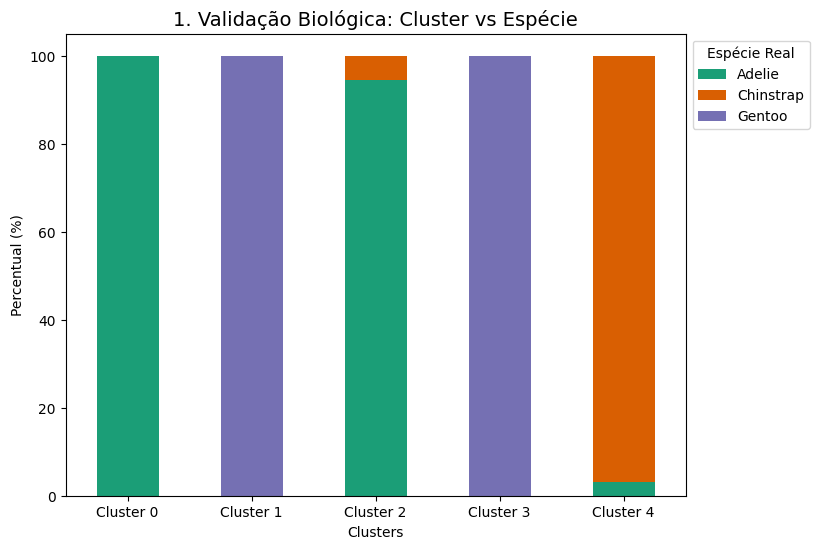

In [20]:
# 1. Cluster vs Espécie Real -> Gráfico de Barras Empilhadas (O melhor para ver "pureza")
plt.figure(figsize=(8, 6))
cruzamento_esp = pd.crosstab(df_final['DS_cluster'], df_final['species'], normalize='index') * 100
cruzamento_esp.plot(kind='bar', stacked=True, color=['#1b9e77','#d95f02','#7570b3'], ax=plt.gca())
plt.title('1. Validação Biológica: Cluster vs Espécie', fontsize=14)
plt.ylabel('Percentual (%)')
plt.xlabel('Clusters')
plt.legend(title='Espécie Real', bbox_to_anchor=(1, 1))
plt.xticks(rotation=0)
plt.show()

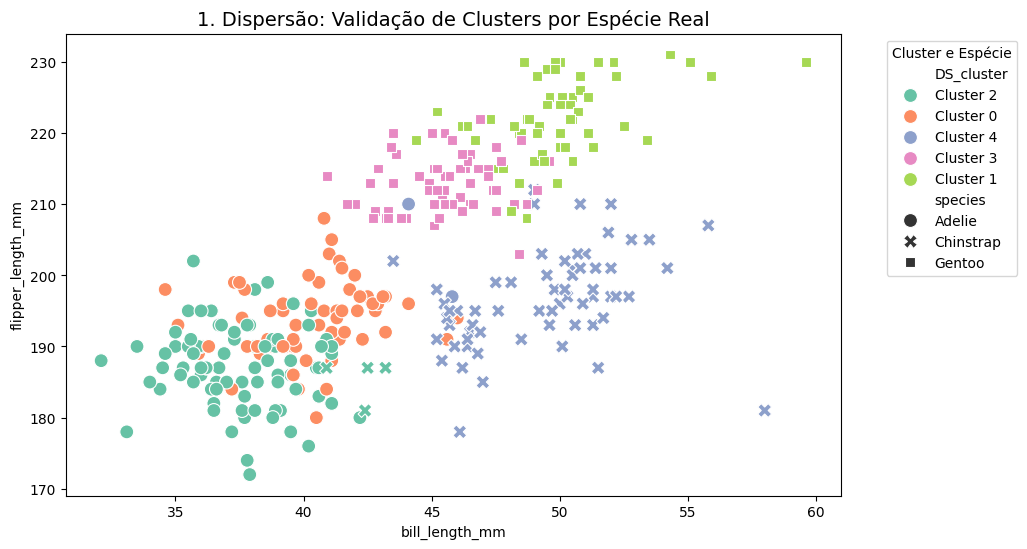

In [21]:
# Cluster vs Espécie
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_final, x='bill_length_mm', y='flipper_length_mm',
                hue='DS_cluster', style='species', s=100, palette='Set2')
plt.title('1. Dispersão: Validação de Clusters por Espécie Real', fontsize=14)
plt.legend(title='Cluster e Espécie', bbox_to_anchor=(1.05, 1))
plt.show()

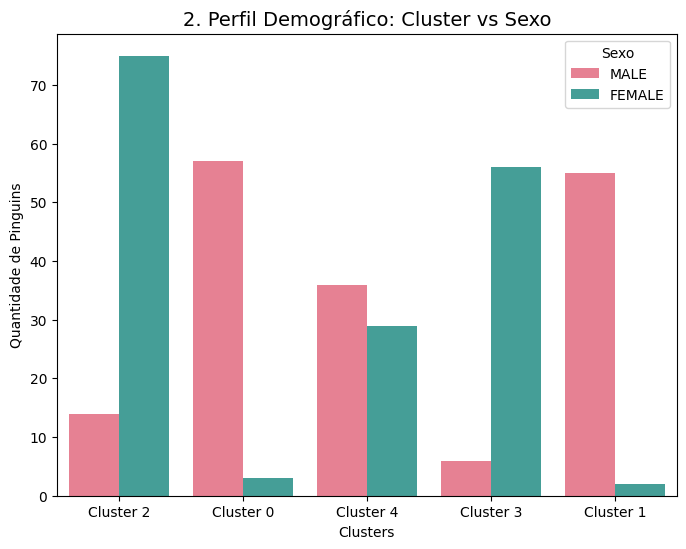

In [22]:
# Cluster vs Sexo
plt.figure(figsize=(8, 6))
sns.countplot(data=df_final, x='DS_cluster', hue='sex', palette='husl')
plt.title('2. Perfil Demográfico: Cluster vs Sexo', fontsize=14)
plt.ylabel('Quantidade de Pinguins')
plt.xlabel('Clusters')
plt.legend(title='Sexo')
plt.show()

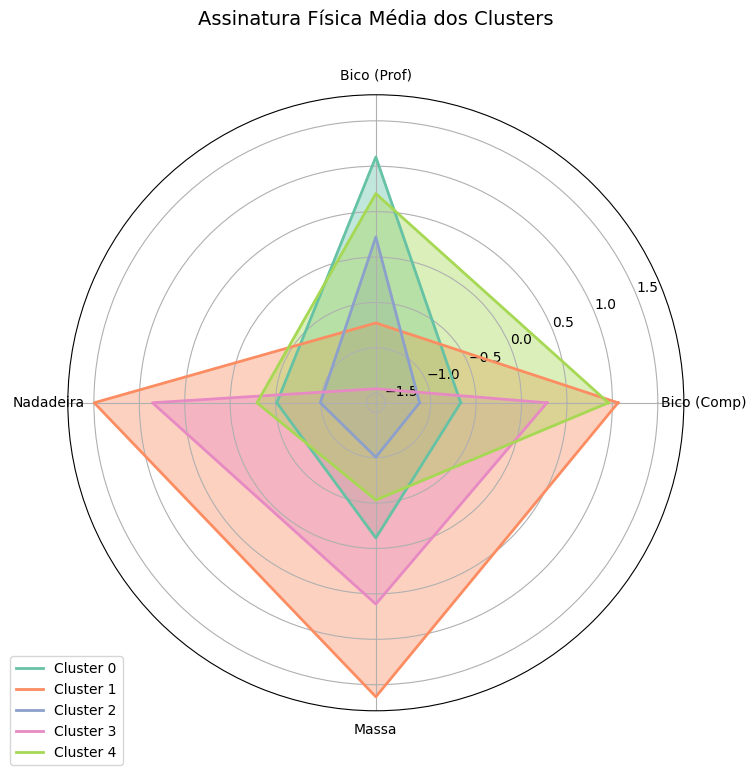

In [24]:
from math import pi

categorias = ['Bico (Comp)', 'Bico (Prof)', 'Nadadeira', 'Massa']
N = len(categorias)
ângulos = [n / float(N) * 2 * pi for n in range(N)]
ângulos += ângulos[:1]
colunas_radar = [
    'bill_length_mm_PADRONIZADA', 'bill_depth_mm_PADRONIZADA',
    'flipper_length_mm_PADRONIZADA', 'body_mass_g_PADRONIZADA'
]
df_radar = df_final.groupby('DS_cluster')[colunas_radar].mean().reset_index()
fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
# Modified: Added more colors to match the 5 clusters
cores = ['#66c2a5', '#fc8d62', '#8da0cb', '#e78ac3', '#a6d854']

for i, cluster in enumerate(df_radar['DS_cluster']):
    valores = df_radar.loc[i].drop('DS_cluster').values.flatten().tolist()
    valores += valores[:1]
    ax.plot(ângulos, valores, linewidth=2, label=cluster, color=cores[i])
    ax.fill(ângulos, valores, color=cores[i], alpha=0.4) # Changed alpha for better visibility
plt.xticks(ângulos[:-1], categorias)
plt.title('Assinatura Física Média dos Clusters', fontsize=14, y=1.1)
plt.legend(loc='upper right', bbox_to_anchor=(0.1, 0.1))
plt.show()